In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.special import factorial 
from scipy import stats
import pandas as pd

import util


plt.rc('text', usetex=True)
plt.rc('font', family='serif')

plt.figure(figsize=(10,6), dpi=300)

<Figure size 3000x1800 with 0 Axes>

<Figure size 3000x1800 with 0 Axes>

In [2]:
# Draw samples from a poissonian distribution
# use pandas to open pendulumData (1).csv
df = pd.read_csv("pendulumData (1).csv")
cutoff = 10

#print columns
print(df.columns)
# need explanation 
def iqr(data):
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    return iqr

iqr_val = iqr(df['g (m/s2)'])

median  = df['g (m/s2)'].median()

pendulum_data = df[np.abs(df['g (m/s2)'] - median) <= iqr_val*cutoff]
pendulum_data_outliers = df[np.abs(df['g (m/s2)'] - median) >= iqr_val*cutoff]

print(pendulum_data_outliers)
counts = pendulum_data[r'g (m/s2)']

# get statistics
mean = counts.mean()
std = counts.std()
err = std/np.sqrt(len(counts))
print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Standard error: {err :.2f}")




Index(['label', 'g (m/s2)', 'stat uncert', 'sys uncert', 'total uncert'], dtype='str')
               label  g (m/s2) stat uncert sys uncert total uncert
4    20.Sep.X.B01.05    978.00          17          8          NaN
50   21.Sep.A.B02.08     12.22        1.29       1.22          NaN
68   21.Sep.A.B04.03     14.60         NaN        NaN          5.3
89   21.Sep.B.B02.07     12.22        1.29       1.22          NaN
226  23.Feb.A.B02.02     15.70         NaN        NaN          3.9
270  23.Sep.A.B02.09      6.95         NaN        NaN         1.07
347  24.Feb.A.B01.04     14.64         NaN        NaN         3.82
370  24.Sep.A.B01.09     12.83         NaN        NaN         1.74
390  24.Sep.A.B03.09     12.40         NaN        NaN          0.3
404  24.Sep.A.B04.11     12.82         NaN        NaN         0.13
466   25.Feb.A.B02.9      0.60         0.1       0.09         0.19
503   25.Sep.A.B03.1     13.00           2        NaN          NaN
510   25.Sep.A.B03.8     13.22         NaN

In [3]:

# Perform fit of histogram to double gaussian
freqs, bins = np.histogram(counts, bins=50)
#normalize frequencies by bin width and total number of counts
normalization = (bins[1] - bins[0]) * len(counts)
sig = np.sqrt(freqs) / normalization # Poissonian uncertainty
freqs = freqs / normalization
bin_centers = 0.5 * (bins[1:] + bins[:-1])


bin_centers, freqs, sig = util.delete_zeros(bin_centers, freqs,sig) # Take out the zeros from our data
popt, pcov = opt.curve_fit(f=util.two_gaussian, xdata=bin_centers, ydata=freqs, sigma=sig, p0=[9, 13, 0.1, 9, 3, 2], absolute_sigma=True) # Fit function
uncert = np.sqrt(np.diag(pcov)) # Extract uncertainty from fit
print(popt)
print(uncert)

[9.80713125 0.18776966 0.06706974 9.79977057 0.18859284 0.48788495]
[0.00515029 0.01443555 0.00513843 0.03164654 0.01440543 0.03067895]


35.60507636208737


<>:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:40: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:40: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_82398/3328124353.py:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.axvline(weighted_mean, color='red', linestyle='--', label=f'$\mu$: {mean:.2f} m/s$^2$')
/tmp/ipykernel_82398/3328124353.py:40: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences

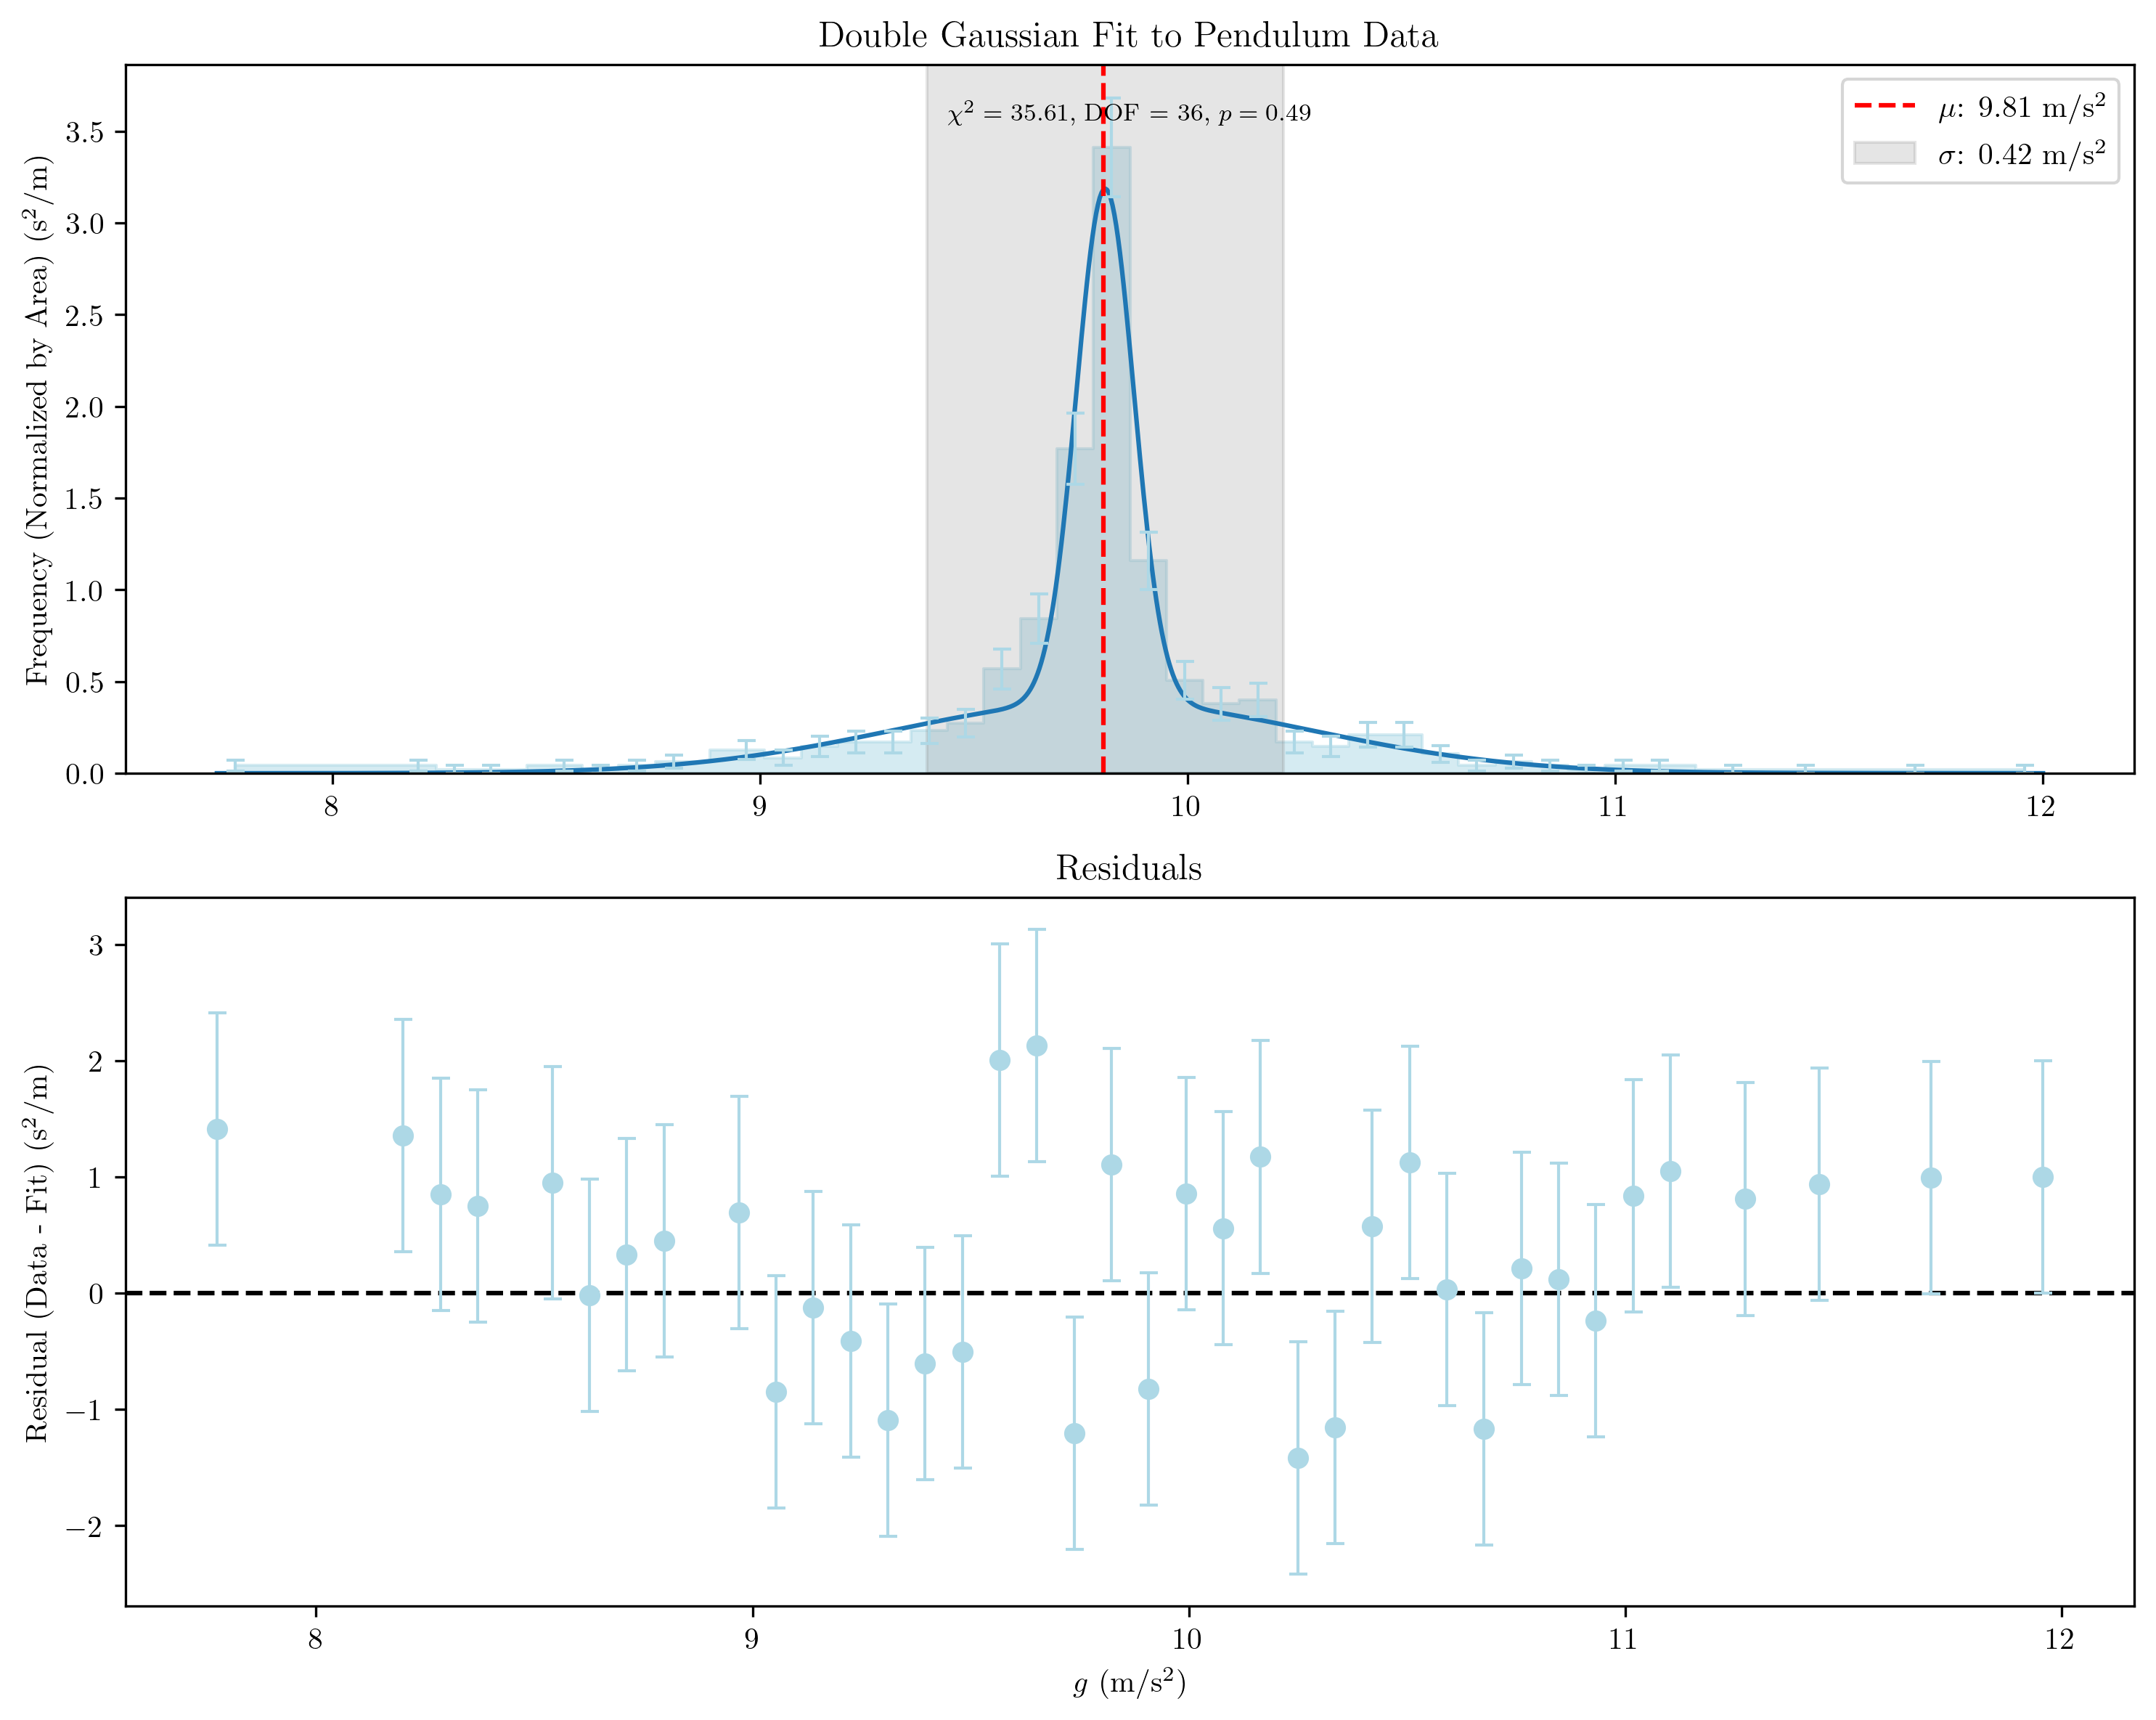

In [4]:

mean = counts.mean()
std = counts.std()
err = std/np.sqrt(len(counts))

mean_1, amp_1, std_1 = popt[0], popt[1], popt[2]
mean_2, amp_2, std_2 = popt[3], popt[4], popt[5]

amp = amp_1 + amp_2
weight_1 = amp_1 / amp
weight_2 = amp_2 / amp

weighted_mean = mean_1 * weight_1 + mean_2 * weight_2

x = np.linspace(start=np.min(counts), stop=np.max(counts), num=1000, endpoint=True)  # Define x for smoother plotting of our poisson fit function

# Plot chi2
chi2 = util.chisq(util.two_gaussian, popt, bin_centers, freqs, sig)
print(chi2)
dof = len(bin_centers) - 2
chi2_probs = 1 - stats.chi2.cdf(chi2, dof)  # Get the probability by subtracting 1 from the cumulative distribution function

# Create subplots
plt.figure(figsize=(10, 8), dpi=300)

plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.fill_between(bin_centers, freqs, step='mid', color='lightblue', alpha=0.5)  # Fill area underneath the step plot
plt.plot(x, util.two_gaussian(x, *popt))  # Plot fit function
plt.errorbar(bin_centers, freqs, yerr=sig, linewidth=1, ls='none', fmt='', capsize=3, color='lightblue')  # Plot actual data

# Add text annotations to the plot with the chi2 value, dof, and chi2 probability
plt.text(0.5, 0.95, r'$\chi^2 = {:.2f}$, DOF = {}, $p = {:.2f}$'.format(chi2, dof, chi2_probs),
         transform=plt.gca().transAxes, ha='center', va='top', fontsize=8)

# Label the x and y axes with units
plt.ylabel(r'Frequency (Normalized by Area) (s$^2$/m)')
plt.title('Double Gaussian Fit to Pendulum Data')
plt.axvline(weighted_mean, color='red', linestyle='--', label=f'$\mu$: {mean:.2f} m/s$^2$')

#fill between mean - stderr and mean + stderr
plt.axvspan(mean - std, mean + std, color='gray', alpha=0.2, label=f'$\sigma$: {std:.2f} m/s$^2$')
plt.legend()
plt.ylim(bottom=0)


## Residuals Plot
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.axhline(0, color='black', linestyle='--')

residuals = (freqs - util.two_gaussian(bin_centers, *popt))/sig
plt.plot(bin_centers, residuals, marker='o', linestyle='none', color='lightblue')
plt.errorbar(bin_centers, residuals, yerr=sig/sig, linewidth=1, ls='none', fmt='', capsize=3, color='lightblue')

plt.xlabel(r'$g$ (m/s$^2$)')
plt.ylabel('Residual (Data - Fit) (s$^2$/m)')
plt.title('Residuals')
### End residuas plot

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()
